# Двудольность. Проверка графа на двудольность
---
> Двудольный граф - граф, вершины которого можно разбить на два множества так, что каждое ребро соединяет вершины из разных множеств.

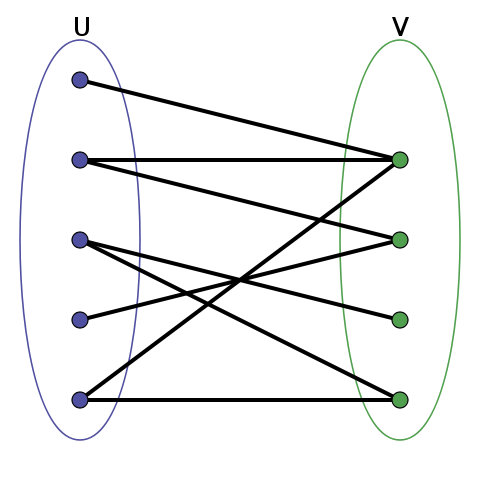


Часто в контексте двудольных графов используется понятие цвета вершины. Разбитие графа на две доли называется покраской его вершин в два различных цвета. Каждое ребро должно соединять вершины различного цвета.

Существует ещё один признак двудольности графа: граф является двудольным тогда и только тогда, когда в нём отсутствуют циклы нечётной длины.

## Проверка графа на двудольность
---
Для проверки графа на двудольность и разбития его на доли чаще всего используется DFS.

Начинаем покраску с произвольной вершины, которую красим в произвольный цвет. При прохождении по каждому ребру красим следующую вершину в противоположный цвет. Если при переборе соседних вершин мы нашли вершину, уже покрашенную в тот же цвет, что и текущая, то в графе существует нечётный цикл, а значит, он не является двудольным.

### Реализация:
Вместо списка visited заведём список color, в котором будем хранить 0 для непосещенных вершин, а для остальных 1 или 2 — их цвет. Алгоритм DFS для каждого ребра будет проверять цвет его конечной вершины. Непосещённая вершина красится в цвет, неравный цвету текущей. Если вершина была посещена, то ребро пропускается если его концы разноцветные, иначе делается пометка, что граф не является двудольным.

In [ ]:
def is_bipartite(graph_array: list[list[int]]) -> bool:
  colors = [0] * n
  res = True

  def dfs(start: int) -> None:
    for v in graph_array[start]:
      if colors[v] == 0:
        colors[v] = 3 - colors[start]
        dfs_bebebe(v)
      elif colors[v] == colors[start]:
        res = False
        break

  for i in range(len(graph_array)):
    if colors[i] == 0:
      colors[i] = 1
      dfs_bebebe(i)

  return res

# Проверка графа на ацикличность. Нахождение цикла
---
## Постановка задачи
> Для заданного графа нужно ответить, содержит ли он хотя бы один цикл. Стоит заметить, что от нас не требуется найти все циклы, нужно всего лишь ответить, существует ли хотя бы один. Задача на поиск всех циклов решается гораздо сложнее.
## Алгоритм
Для поиска цикла будем использовать DFS. По наличию ребер, ведущих к уже посещенной вершине, но не к прямому предку, можно судить о наличии цикла в графе:

In [ ]:
def is_cyclic(graph_array: list[list[int]]) -> bool:
  used = [False] * len(graph_array)
  res = False

  def dfs(v, p=-1):
    used[v] = True
    for u in graph_array[v]:
      if not used[u]:
        dfs[u, v]
      elif u != p:
        res = True
        break

  for i in range(len(graph_array)):
    if not used[i]:
      dfs[i]

  return res

Если нужно восстановить сам цикл, то будем записывать вершины цикла, пока выходим из рекурсии

In [ ]:
def find_cycles(graph: list[list[int]]) -> list[list[int]]:
  used = [False] * len(graph)
  cycles = []

  def dfs(v, p=-1):
    if used[v]:
      return v
    used[v] = True
    for u in graph[v]:
      if u != p:
        k = dfs(u, v)
        if k != -1:
          cycle.append(v)
          if k == v:
            return -1
          return k
    return -1

  for i in range(len(graph)):
    if not used[i]:
      cycle = []
      dfs(i)
      cycles.append(cycle)

  return cycles

# Топологическая сортировка
---
Топологическая сортировка (Topological sort) — один из основных алгоритмов на графах, который применяется для решения множества более сложных задач.

Задача топологической сортировки графа состоит в следующем: указать такой линейный порядок на его вершинах, чтобы любое ребро вело от вершины с меньшим номером к вершине с большим номером. Очевидно, что если в графе есть циклы, то такого порядка не существует.

Простой пример работы алгоритма - https://habr.com/ru/articles/100953/

In [ ]:
from collections import defaultdict


#Класс для представления графа
class Graph:
    def __init__(self,vertices):
        self.graph = defaultdict(list) #dictionary containing adjacency List
        self.V = vertices #No. of vertices

    # Функция для добавления ребра в граф
    def addEdge(self,u,v):
        self.graph[u].append(v)

    # Рекурсивная функция, используемая topologicalSort
    def topologicalSortUtil(self,v,visited,stack):

        # Помечаем текущий узел как посещенный
        visited[v] = True

        # Рекурсивно вызываем функцию для всех смежных вершин
        for i in self.graph[v]:
            if visited[i] == False:
                self.topologicalSortUtil(i,visited,stack)

        # Добавляем текущую вершину в стек с результатом
        stack.insert(0,v)

    # Функция для поиска топологической сортировки.
    # Рекурсивно использует topologicalSortUtil()
    def topologicalSort(self):
        # Помечаем все вершины как непосещенные
        visited = [False]*self.V
        stack =[]

        # Вызываем рекурсивную вспомогательную функцию
        # для поиска топологической сортировки для каждой вершины
        for i in range(self.V):
            if visited[i] == False:
                self.topologicalSortUtil(i,visited,stack)

        # Выводим содержимое стека
        print stack

g= Graph(6)
g.addEdge(5, 2);
g.addEdge(5, 0);
g.addEdge(4, 0);
g.addEdge(4, 1);
g.addEdge(2, 3);
g.addEdge(3, 1);

print "Following is a Topological Sort of the given graph"
g.topologicalSort()

In [ ]:
# Другая реализация

def topological_sort(graph):
  used = [False] * len(graph)
  res = []

  def dfs(start):
    used[start] = True
    for v in graph[start]:
      if not used[v]:
        dfs[v]
    res.append(start)

  for i in range(len(graph)):
    if not used[i]:
      dfs(i)

  return res[::-1]

# Поиск мостов и точек сочленения
---
> Мостом называется ребро, при удалении которого связный неориентированный граф становится несвязным.

> Точкой сочленения называется вершина, при удалении которой связный неориентированный граф становится несвязным.

## Поиск мостов
Суть алгоритма: Мы можем заметить тот факт, что ребро между точками v и u является мостом тогда и только тогда, когда из вершины u и её потомков нельзя вернуться в вершину v или подняться выше нее (при обходе в глубину). Осталось лишь понять, как нам это выяснить.

Будем для каждой вершины v хранить два значения:

f[v] - минимально возможная вершина в которую мы можем опуститься из этой вершины в процессе обхода в глубину (по умолчанию текущая глубина)

h[v] - глубина текущей вершины

В процессе обхода:

Если встречаем вершину u, в которой еще не были, то спускаемся в неё и тогда f[v] = min(f[v], f[u]). Тем самым проверяем опустились ли мы из вершины u и её потомков выше v.

Если встречаем вершину v, в которой уже были, то f[v] = min(f[v], h[u]). Тем самым проверяем не встретили ли мы вершину выше по обходу графа, чем вершина v.

In [ ]:
def find_bridges(graph):
  used = [False] * len(graph)
  h = [0] * len(graph)
  f = [0] * len(graph)
  bridges = []

  def dfs(start, p=-1, curr_h=0):
    curr_h += 1
    h[start] = f[start] = curr_h
    used[start] = True
    for v in graph[start]:
      if v == p:
        continue
      if not used[v]:
        dfs[v, start, curr_h]
        f[start] = min(f[start], f[v])
        if f[v] > h[start]:
          bridges.append((v, start))
      else:
        f[start] = min(f[start], h[v])

  for i in range(len(graph)):
    if not used[i]:
      dfs[i]

  return bridges

## Поиск точек сочленения
### Идея

Мы можем заметить два факта:

Рассмотрим ребро между вершинами v и u. Тогда если из вершины u и ее потомков нельзя попасть в какого-либо предка вершины v и притом вершина v не является корнем дерева, то данная вершина и есть точка сочленения

Если вершина v - корень дерева, то она является точкой сочленения тогда и только тогда, когда эта точка имеет более одного сына в обходе графа в глубину

### Алгоритм
Заведем общий счетчик времени входа timer и два массива:

tin[v] - время входа в вершину v

fup[v] - минимально достижимая вершина из вершины v

Запустим обход графа в глубину (DFS).

В процессе обхода:

Если встречаем уже посещенную вершину u, то fup[v] = min(fup[v], tin[u]). Проверяем не спустились ли мы выше v.

Если встречаем не посещенную вершину v, то спускаемся в неё. Затем fup[v] = min(fup[v], fup[u]). Тем самым проверим не спустились ли мы выше v из вершины u и ее потомков. И наконец если из вершины u нельзя спуститься ниже вершины v и вершина v - не корень дерева обхода графа (v fup[u] >= tin[v] && p != -1), то вершина v и есть искомая точка сочленения. Добавляем 1 к количеству сыновей вершины v (children++)

По завершении обхода:

Если вершина v является корнем обхода графа в глубину и имеет более одного сына, то она также является точкой сочленения (p == -1 && children > 1)

In [ ]:
def find_joint_points(graph):
  timer = 0
  used = [False] * len(graph)
  tin = [0] * len(graph)
  fup = [0] * len(graph)
  ans = []

  def dfs(v, p=-1):
    used[v] = True
    timer += 1
    tin[v] = timer
    fup[v] = timer
    children = 0
    for u in graph[v]:
      if u == p:
        continue
      if used[u]:
        fup[v] = min(fup[v], tin[u])
      else:
        dfs(u, v)
        fup[v] = min(fup[v], fup[u])
        if fup[v] >= tin[v] and p != -1:
          ans.append(v)
        children += 1
    if p == -1 and children > 1:
      ans.append(v)

  for i in range(len(graph)):
    if not used[i]:
      dfs[i]

  return ans

# Задачи

1. Дан взвешенный связный граф. Вершины нумеруются с нуля. Трeбуется с помощью алгоритма Дейкстры восстановить кратчайший путь (по сумме весов) от вершины s до вершины f и найти длину этого пути. 

    Формат входных данных 

    На вход программе в первой строке подается четыре числа через пробел: n , m , s , f . 

    •	2 ≤ n ≤ 1000 - число вершин в графе 

    •	1 ≤ m ≤ 20000 - число ребер 

    •	s и f - номера начальной и конечной вершин, соответственно 

    В следующих m строках задаются ребра, по три числа в каждой строке - номера соединенных вершин и вес ребра. 

    Формат выходных данных 

    Длина (число вершин) кратчайший путь между вершинами s и f. 

    Примеры 

    Ввод:


    2 1 0 1 \
    1 0 5 \
    Вывод:

    2

In [ ]:
import heapq
n, m, s, f = map(int, input().split())
g = [[] for _ in range(n)]
for _ in range(m):
    u, v, w = map(int, input().split())
    g[u].append((v, w))
    g[v].append((u, w))
maxl = 10**8
dist = [maxl]*n
dist[s] = 0
prev = [-1] * n
pq = [(0, s)]
while pq:
    d, v = heapq.heappop(pq)
    if d != dist[v]:
        continue
    for to, w in g[v]:
        nd = d + w
        if nd < dist[to]:
            dist[to] = nd
            prev[to] = v
            heapq.heappush(pq, (nd, to))
ans = []
cur = f
while cur != -1:
    ans.append(cur)
    cur = prev[cur]
ans.reverse()
print(len(ans))


2


2. Дан неориентированный граф c числом узлов V и рёбер E. Проверьте, содержит ли этот граф цикл или нет. Граф задан в виде списка смежности.

    Входные данные

    В первой строке вводятся число узлов V и рёбер E графа. На следующей строке вводится список смежности в виде: {{1}, {0, 2, 4}, {1, 3}, {2, 4}, {1, 3}}

     Выходные данные


    Вывести ‘YES’ если граф содержит циклы и ‘NO’ если циклов в графе нет.

    Пример

    Входные данные:

    5 5

    {{1}, {0, 2, 4}, {1, 3}, {2, 4}, {1, 3}}

    Выходные данные:

    ‘YES’

    Комментарий:
    
    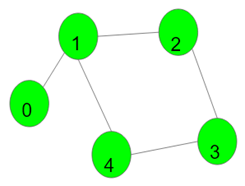
    
    1->2->3->4->1 – цикл.

In [4]:
s = input().split()
v = int(s[0])
e = int(s[1])
ln = input().strip()
if ln.startswith('{{'):
    ln = ln[2:-2]
ps = ln.split('}, {')
g = [[] for _ in range(v)]
for i, p in enumerate(ps):
    p = p.strip()
    if p:
        nums = p.split(',')
        for x in nums:
            x = x.strip()
            if x:
                g[i].append(int(x))
vis = [False] * v
cyc = False


def dfs(cur, par):
    global cyc
    vis[cur] = True
    for nxt in g[cur]:
        if not vis[nxt]:
            dfs(nxt, cur)
        elif nxt != par:
            cyc = True


for i in range(v):
    if not vis[i]:
        dfs(i, -1)
if cyc:
    print("YES")
else:
    print("NO")


YES


3. Рассмотрим одну из переговорных комнат в компании. На день планируется N встреч, которые заданы в виде (start[i], end[i]), где start[i] время начала i-й встречи, а end[i] – время окончания i-й встречи. Какое максимальное число встреч можно провести в переговорной комнате, если встречи не могу пересекаться и время начала одной встречи не может быть равно времени окончания другой встречи?

    Входные данные

    В первой строке вводится число собраний, далее во второй строке время начала встреч и не следующей строке время окончания встреч.

    Выходные данные

    Максимальное число встреч, которое можно провести.

    Пример

    Входные данные:

    6 \
    1 3 0 5 8 5 \
    2 4 6 7 9 9

    Выходные данные:

    4

    Комментарий: без пересечений можно провести встречи - (1, 2), (3, 4), (5,7) и (8,9).

In [3]:
n = int(input())
st = list(map(int, input().split()))
en = list(map(int, input().split()))
m = []
for i in range(n):
    m.append((st[i], en[i]))
m.sort(key=lambda x: x[1])
cnt = 0
le = -1
for s, e in m:
    if s >= le:
        cnt += 1
        le = e
print(cnt)


ValueError: invalid literal for int() with base 10: ''

4. В этой задаче необходимо подсчитать наименьшее время в пути (минут) от одной станции московского метро start до другой end. Вывести минимальный путь, записать его в файл (выбираете подходящую структуру данных) и визуализируете путь (отобразить все станции и кратчайший путь). Станции вводятся на латинице. В качестве решения загружаете код.

    Формат входных данных 

    В первой строке 4 значения через пробел V E start end . 

    •	V - число станций 

    •	E - число соединений между станциями 

    •	start - название отправной станции 

    •	end - название конечной станции 

    Далее следуют E строк в формате name_1 name_2 time : 

    •	name_1 и name_2 - связанные между собой станции метро (железной дорогой или переходом) 

    •	time - время в минутах, которое требуется, чтобы попасть из станции name_1 на станцию name_2 

    Формат выходных данных 

    Одно число — результат. 

    Примеры 

    Ввод:

    6 5 mendeleevskaya serpukhovskaya

    mendeleevskaya tsvetnoy_bulvar 4

    tsvetnoy_bulvar chekhovskaya 3

    chekhovskaya borovitskaya 4

    borovitskaya polyanka 3

    polyanka serpukhovskaya 3

In [ ]:
import heapq
import sys


fk = sys. stdin.readline().split()
V = int(fk[0])
E = int(fk[1])
start = fk[2]
end = fk[3]
nameid = {}
idname = []
edg = []
g = [[] for _ in range(V)]
for _ in range(E):
    line = sys.stdin.readline().split()
    a_name, b_name, t = line[0], line[1], int(line[2])
    if a_name not in nameid:
        nameid[a_name] = len(idname)
        idname.append(a_name)
    if b_name not in nameid:
        nameid[b_name] = len(idname)
        idname.append(b_name)
    a = nameid[a_name]
    b = nameid[b_name]
    g[a].append((b, t))
    g[b].append((a, t))
    edg.append((a, b, t))
s = nameid[start]
f = nameid[end]
maxl = 10**12
dist = [maxl] * V
dist[s] = 0
prev = [-1] * V
pq = [(0, s)]
while pq:
    d, v = heapq.heappop(pq)
    if d != dist[v]:
        continue
    for to, w in g[v]:
        nd = d + w
        if nd < dist[to]:
            dist[to] = nd
            prev[to] = v
            heapq.heappush(pq, (nd, to))
path = []
cur = f
while cur != -1:
    path.append(cur)
    cur = prev[cur]
path.reverse()
print(dist[f])
with open('path.txt', 'w') as file:  # в файлике визуализация
    file.write(' -> '.join(idname[i] for i in path))


5. Дан невзвешенный неориентированный связный граф. Вершины пронумерованы от 0. Трeбуется с помощью обхода в ширину найти расстояния от 0-й до всех остальных вершин. 

    Формат входных данных 

    На вход программе в первой строке подаются через пробел два числа: n (2 <= n <= 1000) — число вершин в графе и m (1 <= m <= 20000) — число рёбер. В следующих m строках задаются ребра: по два числа в каждой строке — номера соединённых вершин. 

    Формат выходных данных 

    Требуется распечатать n чисел, каждое на новой строке. В первой строке — расстояния от 0-й вершины до 0-й, во второй - от 0-й до 1-й, в третьей — от 0-й до 2-й и т.д. 

    Примеры 

    Ввод:

    2 1 \
    1 0 \
    Вывод:

    0 \
    1

In [1]:
from collections import deque

n, m = map(int, input().split())
g = [[] for _ in range(n)]
for _ in range(m):
    u, v = map(int, input().split())
    g[u].append(v)
    g[v].append(u)
dist = [-1] * n
dist[0] = 0
q = deque([0])
while q:
    v = q.popleft()
    for to in g[v]:
        if dist[to] == -1:
            dist[to] = dist[v] + 1
            q.append(to)
for d in dist:
    print(d)


0
1


6. Неориентированный граф задан в формате списка рёбер. При помощи обхода в глубину подсчитать количество компонент связности. 

    Формат входных данных 

    В первой строке вводится количество вершин N. Вершины без названий, их номера — 0, 1, 2 и т.д. до (N-1)-й включительно. 

    Во второй строке вводится количество рёбер M. Затем вводится M строк, содержащих по два числа через пробел — это номера вершин, задающих ребро графа. Рёбра ненаправленные. 

    Формат выходных данных 

    Одно натуральное число — количество компонент связности графа. 

    Примеры 

    Ввод:


    3 \
    3 \
    0 1 \
    1 2 \
    2 0 \
    Вывод:

    1



In [2]:
n = int(input())
m = int(input())
g = [[] for _ in range(n)]
for _ in range(m):
    u, v = map(int, input().split())
    g[u].append(v)
    g[v].append(u)
vis = [False] * n


def dfs(v):
    vis[v] = True
    for to in g[v]:
        if not vis[to]:
            dfs(to)


cnt = 0
for i in range(n):
    if not vis[i]:
        dfs(i)
        cnt += 1
print(cnt)


1
